# ML Challenge -Fraud Detection in Electricity and Gas Consumption 

This notebook covers the different steps involed in the FDEGCC Challenge. 
The data was downloaded form : [zindi.africa](https://zindi.africa/competitions/fraud-detection-in-electricity-and-gas-consumption-challenge/data)

- Steps not covered in this notebook:
    - The two main .zip files were downloaded and organized into folders.
    - Please read the file descriptions [here](https://zindi.africa/competitions/fraud-detection-in-electricity-and-gas-consumption-challenge/data)

This notebook covers:
- Downloading the data straight from Zindi and onto colab
- Loading the data and carrying out EDA to understand the data and prepare for modelling 
- Preprocessing the data and feature engineering 
- Creating a simple LGBM model and predicting on the test set
- Prepare submission file and save as csv
- Some tips on how to improve model performance and your score

# Phase 1: Data Understanding & EDA

## Step 1: Understanding the Problem

We're working on a fraud detection problem for electricity and gas consumption. We have:

Client data: Customer information (demographics, region, etc.)

Invoice data: Consumption/billing details over time

Target: Binary classification (0 = normal, 1 = fraud)

## Step 2: Initial Setup and Data Loading

In [ ]:
## Pre-Requisites

CURRENT_DIR = Path.cwd()

ROOT_DIR = CURRENT_DIR.parents[0]

DATA_DIR = os.path.join(ROOT_DIR, "data/content")
OUTPUT_DIR = os.path.join(ROOT_DIR, "data/output")

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

In [27]:
## Import Libraries and setup global parameters
# os libs
import os
import sys
from pathlib import Path
# DS libs
import numpy as np
import pandas as pd

# DV libs
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# ML libs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
#import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Set display options for better visualization
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(" Libraries imported successfully!")

 Libraries imported successfully!


In [42]:
## Output Tables
# Set up print options for cleaner output in the console
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

## Plotting
# --- 1. Style Sheet ---
# 'ggplot', 'fivethirtyeight', 'seaborn-v0_8', 'dark_background' are popular.
plt.style.use('seaborn-v0_8') 
# 

# --- 2. Customizing Global Parameters (Fine-tuning) ---

# ====== HELPER FUNCTIONS FOR VIRIDIS VARIATIONS ======

def get_viridis_gradient(n_colors, start=0.2, end=0.8):
    """Get n colors as a gradient from Viridis"""
    return plt.cm.viridis(np.linspace(start, end, n_colors))

def get_viridis_pair(contrast='medium'):
    """Get two contrasting colors from Viridis"""
    if contrast == 'high':
        return [plt.cm.viridis(0.1), plt.cm.viridis(0.9)]  # Dark purple & Yellow
    elif contrast == 'medium':
        return [plt.cm.viridis(0.3), plt.cm.viridis(0.7)]  # Blue & Green-teal
    else:  # low contrast
        return [plt.cm.viridis(0.4), plt.cm.viridis(0.6)]  # Similar colors


# Set a new default color cycle (for lines, bars, etc.)
# Using a Colorblind-Friendly Palette (see Palettes section below)
new_color_cycle = ['#004488', '#DDAA33', '#BB5566', '#009988', '#EE7733'] 
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=new_color_cycle)
# Set global font sizes
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['legend.fontsize'] = 12

# Other common settings
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['grid.alpha'] = 0.5
mpl.rcParams['figure.figsize'] = (10, 6) # Default figure size

# All subsequent calls to plt.plot(), ax.bar(), etc., will use these settings

## Some Colorblind-Friendly Palettes
okabe_ito = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7']	# Excellent for 7-8 categories. High contrast and accessibility.
ibm_design = ['#648fff', '#ffb000', '#dc267f', '#fe6100', '#785ef0', '#000000']	# Modern, bold, and distinct. Good for up to 6 categories.
tols_muted	= ['#332288', '#88CCEE', '#44AA99', '#117733', '#999933', '#DDCC77', '#CC6677']	# Another strong choice, particularly good when printed in grayscale.
matplotlib_tab10 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']	# Matplotlib's default, generally good, but sometimes lacks high contrast.


## Step 3: Load and Explore the Data

In [23]:
 # add root dir to the path
sys.path.insert(0, str(ROOT_DIR))

# Load all datasets
print(" Loading datasets...")

client_train = pd.read_csv(f'{TRAIN_DIR}/client_train.csv', low_memory=False)
invoice_train = pd.read_csv(f'{TRAIN_DIR}/invoice_train.csv', low_memory=False)

client_test = pd.read_csv(f'{TEST_DIR}/client_test.csv', low_memory=False)
invoice_test = pd.read_csv(f'{TEST_DIR}/invoice_test.csv', low_memory=False)

# Sample submission
sample_sub = pd.read_csv(f'{DATA_DIR}/SampleSubmission.csv', low_memory=False)

print(" Data loaded successfully!")
print(f"\n Dataset shapes:")
print(f"Client Train: {client_train.shape}")
print(f"Invoice Train: {invoice_train.shape}")
print(f"Client Test: {client_test.shape}")
print(f"Invoice Test: {invoice_test.shape}")
print(f"Sample Submission: {sample_sub.shape}")

 Loading datasets...
 Data loaded successfully!

 Dataset shapes:
Client Train: (135493, 6)
Invoice Train: (4476749, 16)
Client Test: (58069, 5)
Invoice Test: (1939730, 16)
Sample Submission: (58069, 2)


## Step 4: Exploratory Data Analysis (EDA)

**Variable definitions**

***Invoice data***

- Client_id: Unique id for the client
- Invoice_date: Date of the invoice
- Tarif_type: Type of tax
- Counter_number:
- Counter_statue: takes up to 5 values such as working fine, not working, on hold statue, ect
- Counter_code:
- Reading_remarque: notes that the STEG agent takes during his visit to the client (e.g: If the counter shows something wrong, the agent gives a bad score)
- Counter_coefficient: An additional coefficient to be added when standard consumption is exceeded
- Consommation_level_1: Consumption_level_1
- Consommation_level_2: Consumption_level_2
- Consommation_level_3: Consumption_level_3
- Consommation_level_4: Consumption_level_4
- Old_index: Old index
- New_index: New index
- Months_number: Month number
- Counter_type: Type of counter

***Client:***

- Client_id: Unique id for client
- District: District where the client is
- Client_catg: Category client belongs to
- Region: Area where the client is
- Creation_date: Date client joined
- Target: fraud:1 , not fraud: 0

### 4.1 Prelim inspection

In [28]:
print(" First look at Client Train data:")
print(client_train.head())
print("\n" + "="*50)
print(" First look at Invoice Train data:")
print(invoice_train.head())

 First look at Client Train data:
   disrict          client_id  client_catg  region creation_date  target
0       60     train_Client_0           11     101    31/12/1994    0.00
1       69     train_Client_1           11     107    29/05/2002    0.00
2       62    train_Client_10           11     301    13/03/1986    0.00
3       69   train_Client_100           11     105    11/07/1996    0.00
4       62  train_Client_1000           11     303    14/10/2014    0.00

 First look at Invoice Train data:
        client_id invoice_date  tarif_type  counter_number counter_statue  counter_code  reading_remarque  counter_coefficient  consommation_level_1  consommation_level_2  consommation_level_3  consommation_level_4  old_index  new_index  months_number counter_type
0  train_Client_0   2014-03-24          11         1335667              0           203                 8                    1                    82                     0                     0                     0      14302  

### 4.2 Check Basic Information

In [29]:
print(" Client Train Info:")
print(client_train.info())
print("\n" + "="*50)
print(" Invoice Train Info:")
print(invoice_train.info())

 Client Train Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   disrict        135493 non-null  int64  
 1   client_id      135493 non-null  object 
 2   client_catg    135493 non-null  int64  
 3   region         135493 non-null  int64  
 4   creation_date  135493 non-null  object 
 5   target         135493 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 6.2+ MB
None

 Invoice Train Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   client_id             object
 1   invoice_date          object
 2   tarif_type            int64 
 3   counter_number        int64 
 4   counter_statue        object
 5   counter_code          int64 
 6   reading_remarque      int64 
 7

### 4.3 Check for Missing Values


In [30]:

print(" Missing Values Analysis:")
print("\nClient Train Missing Values:")
print(client_train.isnull().sum())
print("\nInvoice Train Missing Values:")
print(invoice_train.isnull().sum())

 Missing Values Analysis:

Client Train Missing Values:
disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
target           0
dtype: int64

Invoice Train Missing Values:
client_id               0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
                       ..
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
Length: 16, dtype: int64


### 4.4 Target variable analysis

 Target Variable Distribution:
Class 0 (Normal): 127927 (94.42%)
Class 1 (Fraud): 7566 (5.58%)


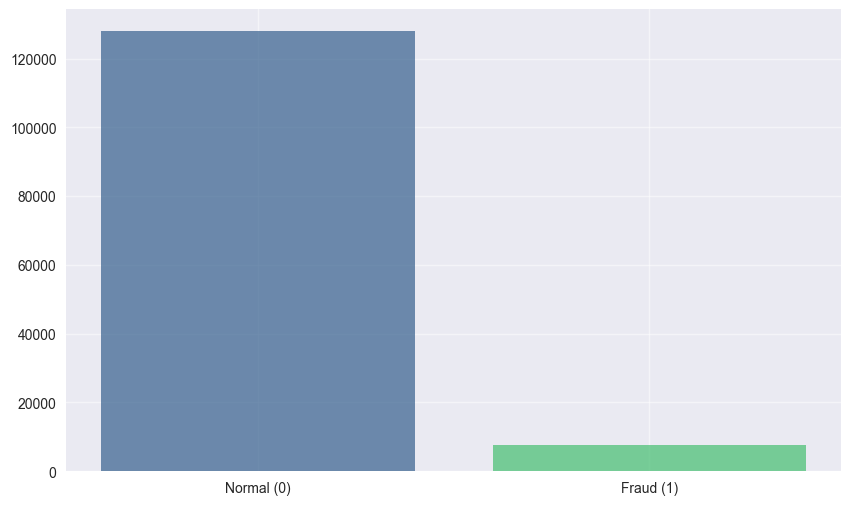

ValueError: Image size of 868x59102332 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 1000x600 with 1 Axes>


 Note: This is an IMBALANCED dataset (fraud cases are rare)!


In [32]:

print(" Target Variable Distribution:")
target_dist = client_train['target'].value_counts()
print(f"Class 0 (Normal): {target_dist[0]} ({target_dist[0]/len(client_train)*100:.2f}%)")
print(f"Class 1 (Fraud): {target_dist[1]} ({target_dist[1]/len(client_train)*100:.2f}%)")

# Visualize

# Extract two colors from Viridis (e.g., at 30% and 70% of the scale)
viridis_colors = plt.cm.viridis([0.3, 0.7])

plt.figure()
bars = plt.bar(['Normal (0)', 'Fraud (1)'], target_dist.values, 
               color=viridis_colors, alpha=0.7)
plt.show()
plt.title('Target Variable Distribution')
plt.ylabel('Count')

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')
plt.show()

print("\n Note: This is an IMBALANCED dataset (fraud cases are rare)!")

### 4.5 Understand Client Data Features

In [33]:
print(" Client Data Analysis:")
print("\nUnique values in each column:")
for col in client_train.columns:
    if col != 'client_id':
        unique_vals = client_train[col].nunique()
        print(f"{col}: {unique_vals} unique values")
        
print("\n" + "="*50)
print(" Statistical Summary of Client Data:")
print(client_train.describe())

 Client Data Analysis:

Unique values in each column:
disrict: 4 unique values
client_catg: 3 unique values
region: 25 unique values
creation_date: 8088 unique values
target: 2 unique values

 Statistical Summary of Client Data:
        disrict  client_catg    region    target
count 135493.00    135493.00 135493.00 135493.00
mean      63.51        11.51    206.16      0.06
std        3.35         4.42    104.21      0.23
min       60.00        11.00    101.00      0.00
25%       62.00        11.00    103.00      0.00
50%       62.00        11.00    107.00      0.00
75%       69.00        11.00    307.00      0.00
max       69.00        51.00    399.00      1.00


### 4.6 Understand Invoice Data Features

In [34]:
print(" Invoice Data Analysis:")

# Convert date column
invoice_train['invoice_date'] = pd.to_datetime(invoice_train['invoice_date'])

print("\nDate Range:")
print(f"Start: {invoice_train['invoice_date'].min()}")
print(f"End: {invoice_train['invoice_date'].max()}")

print("\n" + "="*50)
print(" Statistical Summary of Numerical Invoice Features:")
numeric_cols = invoice_train.select_dtypes(include=[np.number]).columns
print(invoice_train[numeric_cols].describe())

 Invoice Data Analysis:

Date Range:
Start: 1977-06-09 00:00:00
End: 2019-12-07 00:00:00

 Statistical Summary of Numerical Invoice Features:
       tarif_type    counter_number  counter_code  reading_remarque  counter_coefficient  consommation_level_1  consommation_level_2  consommation_level_3  consommation_level_4  old_index  new_index  months_number
count  4476749.00        4476749.00    4476749.00        4476749.00           4476749.00            4476749.00            4476749.00            4476749.00            4476749.00 4476749.00 4476749.00     4476749.00
mean        20.13   123058699065.18        172.49              7.32                 1.00                410.98                109.32                 20.31                 52.93   17767.00   18349.70          44.83
std         13.47  1657267274261.93        133.89              1.57                 0.31                757.31               1220.12                157.42                875.47   40366.93   40953.21        3128.34
mi

### 4.7 Visualize Key Features

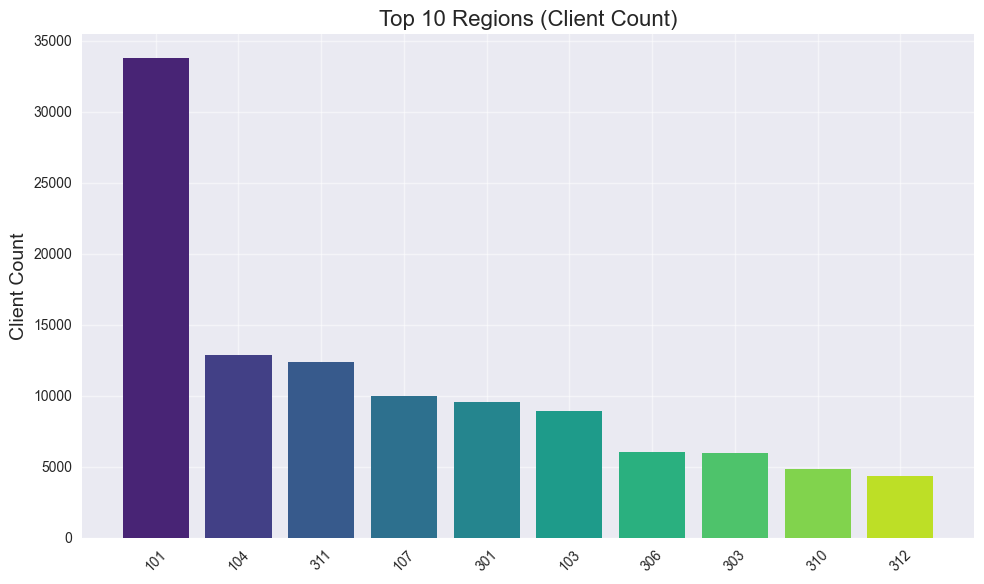

In [43]:
# 1. Region distribution - Gradient of 10 colors
plt.figure()
region_counts = client_train['region'].value_counts().head(10)
region_colors = get_viridis_gradient(len(region_counts), 0.1, 0.9)
bars = plt.bar(range(len(region_counts)), region_counts.values, color=region_colors)
plt.title('Top 10 Regions (Client Count)')
plt.xticks(range(len(region_counts)), region_counts.index, rotation=45)
plt.ylabel('Client Count')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

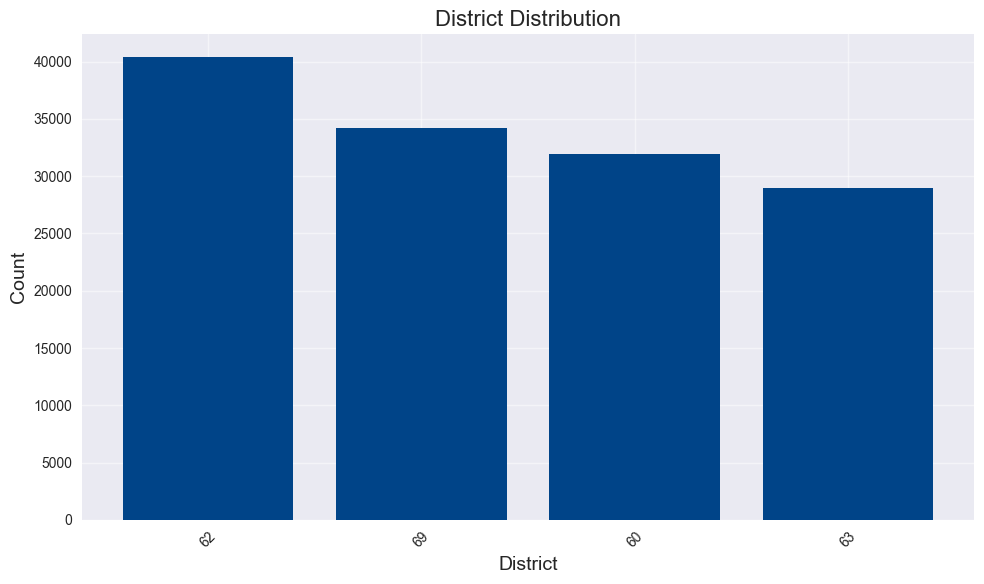

In [ ]:
# 2. District distribution - Sequential gradient
plt.figure()
district_counts = client_train['disrict'].value_counts()
district_colors = get_viridis_gradient(len(district_counts), 0.3, 0.95)
bars = plt.bar(district_counts.index.astype(str), district_counts.values, 
               color=district_colors)
plt.title('District Distribution')
plt.xlabel('District')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

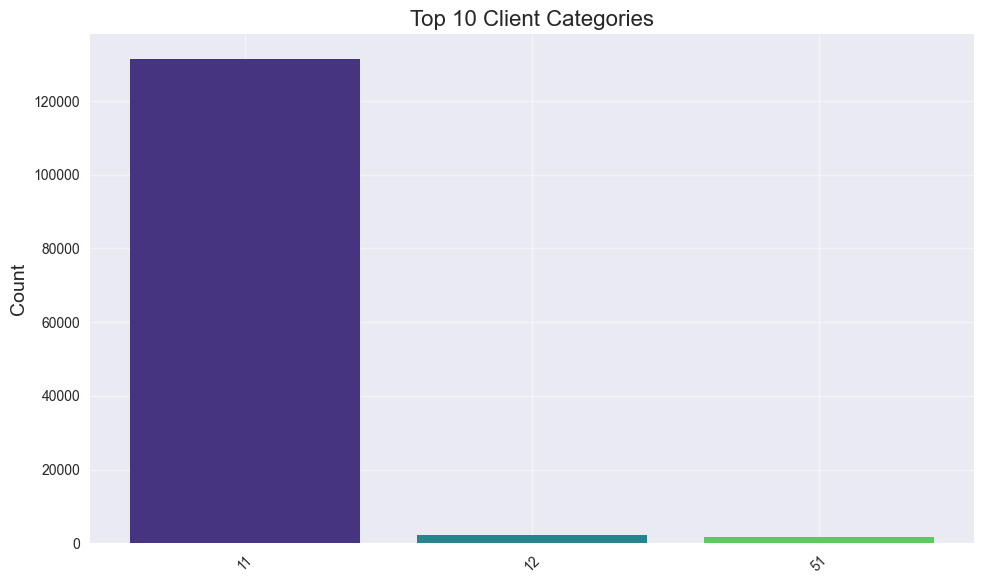

In [44]:
# 3. Client category distribution - Sequential gradient
plt.figure()
catg_counts = client_train['client_catg'].value_counts().head(10)
catg_colors = get_viridis_gradient(len(catg_counts), 0.15, 0.75)
bars = plt.bar(range(len(catg_counts)), catg_counts.values, color=catg_colors)
plt.title('Top 10 Client Categories')
plt.xticks(range(len(catg_counts)), catg_counts.index, rotation=45)
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

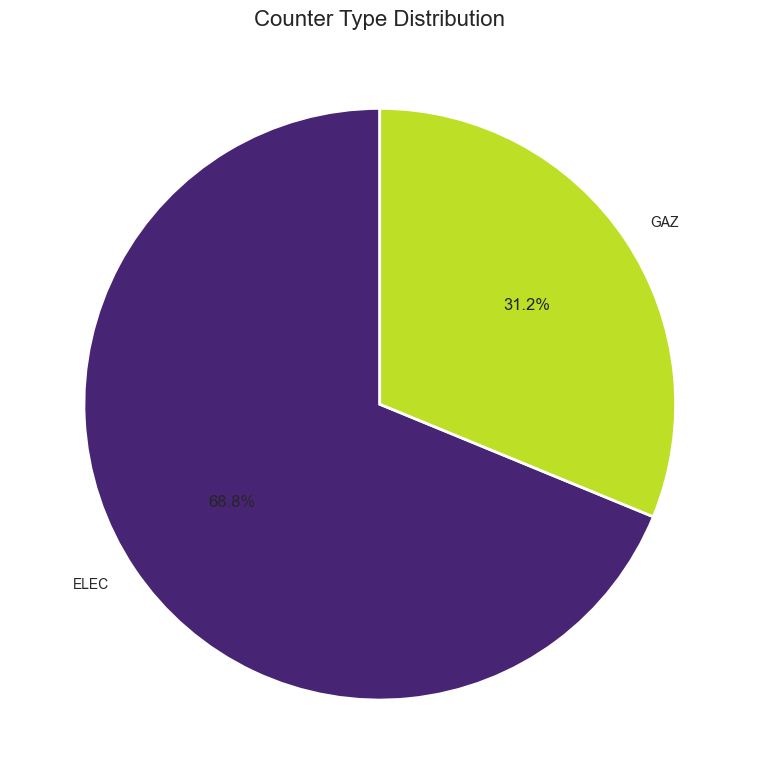

In [45]:
# 4. Counter type distribution - Two contrasting colors
plt.figure(figsize=(8, 8))
counter_type_counts = invoice_train['counter_type'].value_counts()
counter_colors = get_viridis_pair('high')  # High contrast pair
plt.pie(counter_type_counts.values, labels=counter_type_counts.index, 
        autopct='%1.1f%%', colors=counter_colors, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Counter Type Distribution')
plt.tight_layout()
plt.show()


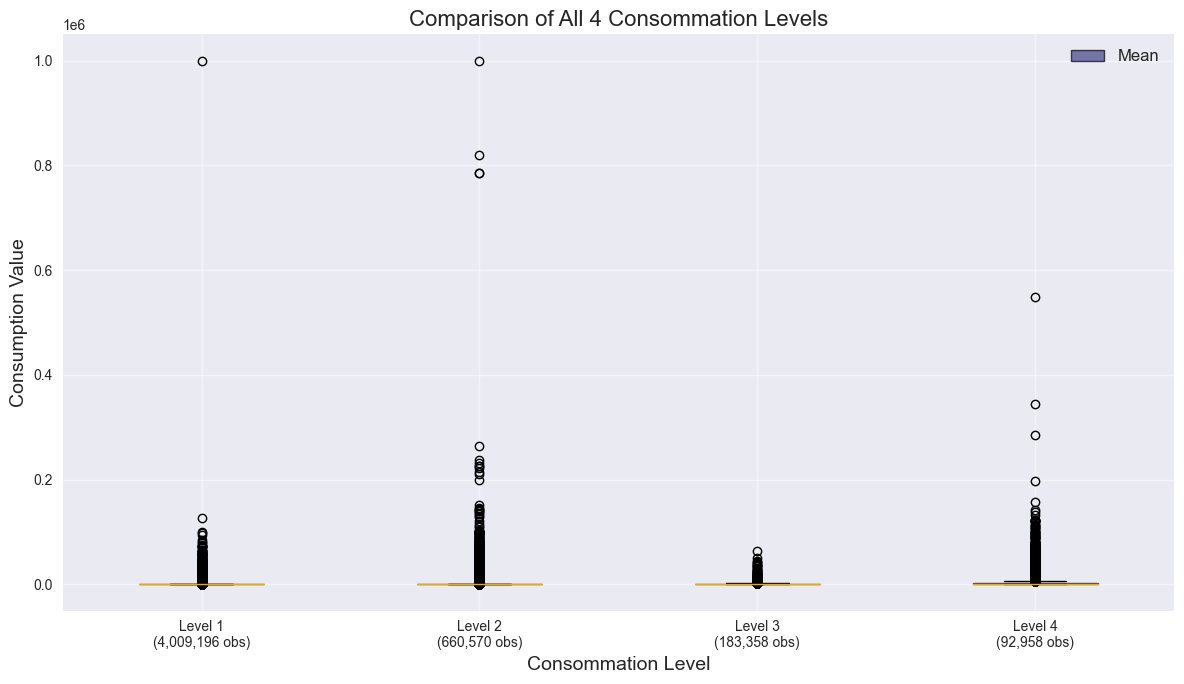

In [49]:
# ====== ALL 4 CONSOMMATION LEVELS ======

# Get all consommation columns
cons_cols = [col for col in invoice_train.columns if 'consommation' in col]

# Boxplot with gradient Viridis colors
plt.figure(figsize=(12, 7))
data_to_plot = []
labels = []
for i, col in enumerate(cons_cols):
    data = invoice_train[col].replace(0, np.nan).dropna()
    data_to_plot.append(data)
    labels.append(f'Level {i+1}\n({len(data):,} obs)')

bp = plt.boxplot(data_to_plot, patch_artist=True, labels=labels)

# Apply gradient Viridis colors to boxes
box_colors = get_viridis_gradient(len(data_to_plot), 0.2, 0.9)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('Comparison of All 4 Consommation Levels')
plt.ylabel('Consumption Value')
plt.xlabel('Consommation Level')
plt.grid(axis='y', alpha=0.5)

plt.legend(['Mean'])
plt.tight_layout()
plt.show()



## Step 5: Data Preprocessing & Feature Engineering

### 5.1 Merge Client and Invoice Data

In [68]:
print("Merging Client and Invoice data...")  # Log aggregation start

def aggregate_invoice_data(invoice_df):
    """Aggregate invoice data by client with proper type handling"""
    
    # Define aggregations based on actual data types
    agg_funcs = {
        # Numeric columns - statistical aggregations
        'tarif_type': ['mean', 'nunique'],  # Average tariff type and count of unique types
        'counter_code': ['nunique'],  # Count distinct counter codes per client
        'reading_remarque': ['mean'],  # Average reading remark value
        'counter_coefficient': ['mean', 'std'],  # Mean and variability of counter coefficients
        'consommation_level_1': ['mean', 'sum', 'std', 'min', 'max'],  # Full consumption statistics for level 1
        'consommation_level_2': ['mean', 'sum', 'std', 'min', 'max'],  # Full consumption statistics for level 2
        'consommation_level_3': ['mean', 'sum', 'std', 'min', 'max'],  # Full consumption statistics for level 3
        'consommation_level_4': ['mean', 'sum', 'std', 'min', 'max'],  # Full consumption statistics for level 4
        'old_index': ['mean', 'std'],  # Average and variability of old meter readings
        'new_index': ['mean', 'std'],  # Average and variability of new meter readings
        'months_number': ['mean', 'sum'],  # Average months per invoice and total months covered
        
        # String/Object columns - use first (most recent) and nunique
        'counter_statue': ['first', 'nunique'],  # Most recent status and count of status changes
        'counter_type': ['first', 'nunique'],  # Most recent counter type and variety of types
        
        # Counter number - count distinct counters
        'counter_number': ['nunique']  # Count of distinct counter numbers per client
    }
    
    # Only use columns that actually exist in the dataframe
    existing_cols = [col for col in agg_funcs.keys() if col in invoice_df.columns]  # Filter to available columns
    filtered_agg_funcs = {col: agg_funcs[col] for col in existing_cols}  # Create filtered aggregation dictionary
    
    print(f"Aggregating {len(existing_cols)} columns: {existing_cols}")  # Show aggregation progress
    
    # Perform aggregation
    agg_df = invoice_df.groupby('client_id').agg(filtered_agg_funcs)  # Group by client and apply aggregations
    
    # Flatten column names
    agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]  # Convert MultiIndex to flat column names
    
    # Add count features
    count_features = invoice_df.groupby('client_id').size().reset_index(name='invoice_count')  # Count invoices per client
    agg_df = agg_df.reset_index().merge(count_features, on='client_id', how='left')  # Merge invoice count with aggregated data
    
    # Add date features
    invoice_df['invoice_date'] = pd.to_datetime(invoice_df['invoice_date'])  # Convert invoice date to datetime
    date_features = invoice_df.groupby('client_id')['invoice_date'].agg([  # Extract date statistics
        'min', 'max', 'nunique'  # First invoice, last invoice, unique invoice dates
    ]).reset_index()
    date_features.columns = ['client_id', 'first_invoice', 'last_invoice', 'unique_dates']  # Rename date columns
    date_features['invoice_span_days'] = (date_features['last_invoice'] - date_features['first_invoice']).dt.days  # Calculate total observation period
    
    agg_df = agg_df.merge(date_features, on='client_id', how='left')  # Merge date features with aggregated data
    
    return agg_df  # Return client-level aggregated dataframe

# Aggregate train and test invoice data
print("Processing train invoices...")  # Indicate train data processing start
train_agg = aggregate_invoice_data(invoice_train)  # Aggregate training invoice data

print("Processing test invoices...")  # Indicate test data processing start
test_agg = aggregate_invoice_data(invoice_test)  # Aggregate testing invoice data

print(f"\nAggregation complete!")  # Confirm aggregation completion
print(f"Train aggregated shape: {train_agg.shape}")  # Show training data dimensions
print(f"Test aggregated shape: {test_agg.shape}")  # Show testing data dimensions


Merging Client and Invoice data...
Processing train invoices...
Aggregating 14 columns: ['tarif_type', 'counter_code', 'reading_remarque', 'counter_coefficient', 'consommation_level_1', 'consommation_level_2', 'consommation_level_3', 'consommation_level_4', 'old_index', 'new_index', 'months_number', 'counter_statue', 'counter_type', 'counter_number']
Processing test invoices...
Aggregating 14 columns: ['tarif_type', 'counter_code', 'reading_remarque', 'counter_coefficient', 'consommation_level_1', 'consommation_level_2', 'consommation_level_3', 'consommation_level_4', 'old_index', 'new_index', 'months_number', 'counter_statue', 'counter_type', 'counter_number']

Aggregation complete!
Train aggregated shape: (135493, 43)
Test aggregated shape: (58069, 43)


### 5.2 Merge with Client Data

In [ ]:
# Merge aggregated invoice data with client data
print("\n Merging with client data...")

train_data = client_train.merge(train_agg, on='client_id', how='left')
test_data = client_test.merge(test_agg, on='client_id', how='left')

print(f"Final train data shape: {train_data.shape}")
print(f"Final test data shape: {test_data.shape}")

# Check the merged data
print("\n Merged data columns:")
print(train_data.columns.tolist())


 Merging with client data...
Final train data shape: (135493, 48)
Final test data shape: (58069, 47)

 Merged data columns:
['disrict', 'client_id', 'client_catg', 'region', 'creation_date', 'target', 'tarif_type_mean', 'tarif_type_nunique', 'counter_code_nunique', 'reading_remarque_mean', 'counter_coefficient_mean', 'counter_coefficient_std', 'consommation_level_1_mean', 'consommation_level_1_sum', 'consommation_level_1_std', 'consommation_level_1_min', 'consommation_level_1_max', 'consommation_level_2_mean', 'consommation_level_2_sum', 'consommation_level_2_std', 'consommation_level_2_min', 'consommation_level_2_max', 'consommation_level_3_mean', 'consommation_level_3_sum', 'consommation_level_3_std', 'consommation_level_3_min', 'consommation_level_3_max', 'consommation_level_4_mean', 'consommation_level_4_sum', 'consommation_level_4_std', 'consommation_level_4_min', 'consommation_level_4_max', 'old_index_mean', 'old_index_std', 'new_index_mean', 'new_index_std', 'months_number_mean

: 

### 5.3 Handle Missing Values

In [69]:
print("Checking missing values...")

# Check missing values
print("Train missing:", train_data.isnull().sum()[train_data.isnull().sum() > 0])
print("Test missing:", test_data.isnull().sum()[test_data.isnull().sum() > 0])

print("\nFilling missing values...")

# Identify columns
num_cols = train_data.select_dtypes(include=np.number).columns.difference(['target'])
cat_cols = train_data.select_dtypes(include='object').columns.difference(['client_id'])

# Fill numerical columns with train medians (skipping target)
for col in num_cols:
    median_val = train_data[col].median()
    train_data[col].fillna(median_val, inplace=True)
    if col in test_data.columns:
        test_data[col].fillna(median_val, inplace=True)

# Fill categorical columns with train modes
for col in cat_cols:
    mode_val = train_data[col].mode()[0] if not train_data[col].mode().empty else 'Unknown'
    train_data[col].fillna(mode_val, inplace=True)
    if col in test_data.columns:
        test_data[col].fillna(mode_val, inplace=True)

print("Missing values filled!")

Checking missing values...
Train missing: Series([], dtype: int64)
Test missing: Series([], dtype: int64)

Filling missing values...
Missing values filled!


### 5.4 Encode Categorical Variables

Encoding transforms the business data (regions, client types, tariff plans) into mathematical representations that machine learning algorithms can process to find patterns in electricity consumption and fraud detection.

In [70]:
print("Encoding categorical variables...")

# Find object columns that aren't ID/target
cat_cols = train_data.select_dtypes(include='object').columns.difference(['client_id', 'target'])

print(f"Categorical columns: {list(cat_cols)}")

# Convert all to string first (handles mixed types)
for col in cat_cols:
    train_data[col] = train_data[col].astype(str)
    if col in test_data.columns:
        test_data[col] = test_data[col].astype(str)

# Simple label encoding
for col in cat_cols:
    le = LabelEncoder()
    train_data[col] = le.fit_transform(train_data[col])
    if col in test_data.columns:
        test_data[col] = le.transform(test_data[col])

print("Encoding complete!")

Encoding categorical variables...
Categorical columns: []
Encoding complete!


### 5.5 Create Additional Features

In [64]:
print("➕ Creating additional features...")

# 1. Consumption ratios
train_data['cons_total'] = train_data['consommation_level_1_sum'] + \
                          train_data['consommation_level_2_sum'] + \
                          train_data['consommation_level_3_sum'] + \
                          train_data['consommation_level_4_sum']

test_data['cons_total'] = test_data['consommation_level_1_sum'] + \
                         test_data['consommation_level_2_sum'] + \
                         test_data['consommation_level_3_sum'] + \
                         test_data['consommation_level_4_sum']

# 2. Consumption per invoice
train_data['cons_per_invoice'] = train_data['cons_total'] / train_data['invoice_count']
test_data['cons_per_invoice'] = test_data['cons_total'] / test_data['invoice_count']

# 3. Variability features
train_data['cons_variability'] = (train_data['consommation_level_1_std'] + \
                                 train_data['consommation_level_2_std'] + \
                                 train_data['consommation_level_3_std'] + \
                                 train_data['consommation_level_4_std']) / 4
test_data['cons_variability'] = (test_data['consommation_level_1_std'] + \
                                test_data['consommation_level_2_std'] + \
                                test_data['consommation_level_3_std'] + \
                                test_data['consommation_level_4_std']) / 4

# 4. Days between invoices
train_data['days_between_invoices'] = train_data['invoice_span_days'] / train_data['invoice_count']
test_data['days_between_invoices'] = test_data['invoice_span_days'] / test_data['invoice_count']

print(f" Added {4} new features!")
print(f"Final train shape: {train_data.shape}")
print(f"Final test shape: {test_data.shape}")

➕ Creating additional features...
 Added 4 new features!
Final train shape: (135493, 52)
Final test shape: (58069, 51)


In [66]:
train_data.head(5)

,disrict,client_id,client_catg,region,creation_date,target,tarif_type_mean,tarif_type_nunique,counter_code_nunique,reading_remarque_mean,counter_coefficient_mean,counter_coefficient_std,consommation_level_1_mean,consommation_level_1_sum,consommation_level_1_std,consommation_level_1_min,consommation_level_1_max,consommation_level_2_mean,consommation_level_2_sum,consommation_level_2_std,consommation_level_2_min,consommation_level_2_max,consommation_level_3_mean,consommation_level_3_sum,consommation_level_3_std,consommation_level_3_min,consommation_level_3_max,consommation_level_4_mean,consommation_level_4_sum,consommation_level_4_std,consommation_level_4_min,consommation_level_4_max,old_index_mean,old_index_std,new_index_mean,new_index_std,months_number_mean,months_number_sum,counter_statue_first,counter_statue_nunique,counter_type_first,counter_type_nunique,counter_number_nunique,invoice_count,first_invoice,last_invoice,unique_dates,invoice_span_days,cons_total,cons_per_invoice,cons_variability,days_between_invoices
0,60,train_Client_0,11,101,8292,0.00,11.00,1,2,6.97,1.00,0.00,352.40,12334,310.34,38,1200,10.57,370,43.57,0,186,0.00,0,0.00,0,0,0.00,0,0.00,0,0,9444.54,4527.74,9807.51,4579.67,4.63,162,0,1,0,1,1,35,2005-10-17,2019-03-19,35,4901,12704,362.97,88.48,140.03
1,69,train_Client_1,11,107,7624,0.00,11.00,1,1,7.22,1.00,0.00,557.54,20629,197.94,190,1207,0.00,0,0.00,0,0,0.00,0,0.00,0,0,0.00,0,0.00,0,0,14330.76,6124.13,14888.30,6119.72,4.32,160,0,1,0,1,1,37,2005-10-19,2019-04-02,37,4913,20629,557.54,49.48,132.78
2,62,train_Client_10,11,301,3067,0.00,11.00,1,2,7.06,1.00,0.00,798.61,14375,513.84,188,2400,37.89,682,160.75,0,682,0.00,0,0.00,0,0,0.00,0,0.00,0,0,32873.00,5317.18,33709.50,5543.23,6.44,116,0,1,0,1,1,18,2005-11-10,2019-05-02,18,4921,15057,836.50,168.65,273.39
3,69,train_Client_100,11,105,2622,0.00,11.00,1,1,6.15,1.00,0.00,1.20,24,3.61,0,15,0.00,0,0.00,0,0,0.00,0,0.00,0,0,0.00,0,0.00,0,0,94.15,4.12,95.35,5.94,4.20,84,0,1,0,1,1,20,2005-06-10,2012-09-25,20,2664,24,1.20,0.90,133.20
4,62,train_Client_1000,11,303,3502,0.00,11.00,1,1,8.86,1.00,0.00,663.71,9292,224.83,124,800,104.86,1468,167.16,0,400,117.36,1643,289.43,0,800,36.71,514,105.42,0,382,6900.43,4732.11,7823.07,4548.67,3.71,52,0,1,0,1,1,14,2015-02-13,2019-06-17,14,1585,12917,922.64,196.71,113.21


In [67]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 52 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   disrict                    135493 non-null  int64         
 1   client_id                  135493 non-null  object        
 2   client_catg                135493 non-null  int64         
 3   region                     135493 non-null  int64         
 4   creation_date              135493 non-null  int64         
 5   target                     135493 non-null  float64       
 6   tarif_type_mean            135493 non-null  float64       
 7   tarif_type_nunique         135493 non-null  int64         
 8   counter_code_nunique       135493 non-null  int64         
 9   reading_remarque_mean      135493 non-null  float64       
 10  counter_coefficient_mean   135493 non-null  float64       
 11  counter_coefficient_std    135493 non-null  float64 

## Step 6: Prepare Data for Modeling

In [65]:
print(" Preparing data for modeling...")

# Separate features and target
X = train_data.drop(['client_id', 'target', 'first_invoice', 'last_invoice'], axis=1, errors='ignore')
y = train_data['target']

# For test data (no target)
X_test = test_data.drop(['client_id', 'first_invoice', 'last_invoice'], axis=1, errors='ignore')

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Test features shape: {X_test.shape}")

# Handle infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Fill any remaining NaN values
X.fillna(X.median(), inplace=True)
X_test.fillna(X.median(), inplace=True)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain/Validation split:")
print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")

 Preparing data for modeling...
Features shape: (135493, 48)
Target shape: (135493,)
Test features shape: (58069, 48)

Train/Validation split:
Train: (108394, 48)
Validation: (27099, 48)


# Step 7: Build and Train LGBM Model

In [ ]:
#Getting unique values on the invoice train data
for col in invoice_train.columns:
    print(f"{col} - {invoice_train[col].nunique()}")

client_id - 135493
invoice_date - 8275
tarif_type - 17
counter_number - 201893
counter_statue - 12
counter_code - 42
reading_remarque - 8
counter_coefficient - 16
consommation_level_1 - 8295
consommation_level_2 - 12576
consommation_level_3 - 2253
consommation_level_4 - 12075
old_index - 155648
new_index - 157980
months_number - 1370
counter_type - 2


In [ ]:
#Getting unique values on the invoice train data
for col in client_train.columns:
    print(f"{col} - {client_train[col].nunique()}")

disrict - 4
client_id - 135493
client_catg - 3
region - 25
creation_date - 8088
target - 2


No missing values in train set

Target is highly imbalanced with fewer cases of fraudulent activities

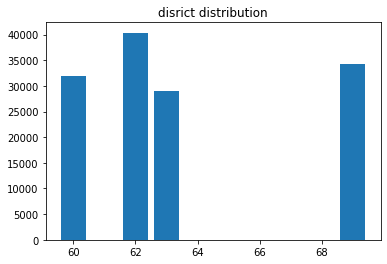

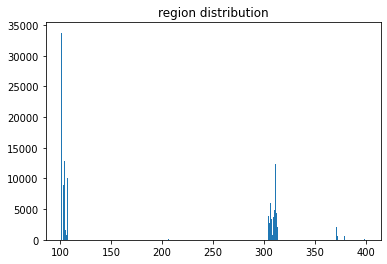

In [ ]:
#Visualize client distribution across districts and regions
for col in ['disrict','region']:
    region = client_train.groupby([col])['client_id'].count()
    plt.bar(x=region.index, height=region.values)
    plt.title(col+' distribution')
    plt.show()

## Feature Engineering

In [ ]:
#convert the column invoice_date to date time format on both the invoice train and invoice test
for df in [invoice_train,invoice_test]:
    df['invoice_date'] = pd.to_datetime(df['invoice_date'])

In [ ]:
#encode labels in categorical column
d={"ELEC":0,"GAZ":1}
invoice_train['counter_type']=invoice_train['counter_type'].map(d)
invoice_test['counter_type']=invoice_test['counter_type'].map(d)

In [ ]:
#convert categorical columns to int for model
client_train['client_catg'] = client_train['client_catg'].astype(int)
client_train['disrict'] = client_train['disrict'].astype(int)

client_test['client_catg'] = client_test['client_catg'].astype(int)
client_test['disrict'] = client_test['disrict'].astype(int)

In [ ]:
def aggregate_by_client_id(invoice_data):
    aggs = {}
    aggs['consommation_level_1'] = ['mean']
    aggs['consommation_level_2'] = ['mean']
    aggs['consommation_level_3'] = ['mean']
    aggs['consommation_level_4'] = ['mean']

    agg_trans = invoice_data.groupby(['client_id']).agg(aggs)
    agg_trans.columns = ['_'.join(col).strip() for col in agg_trans.columns.values]
    agg_trans.reset_index(inplace=True)

    df = (invoice_data.groupby('client_id')
            .size()
            .reset_index(name='{}transactions_count'.format('1')))
    return pd.merge(df, agg_trans, on='client_id', how='left')

In [ ]:
#group invoice data by client_id
agg_train = aggregate_by_client_id(invoice_train)

In [ ]:
print(agg_train.shape)
agg_train.head()

(135493, 6)


,client_id,1transactions_count,consommation_level_1_mean,consommation_level_2_mean,consommation_level_3_mean,consommation_level_4_mean
0,train_Client_0,35,352.400000,10.571429,0.000000,0.000000
1,train_Client_1,37,557.540541,0.000000,0.000000,0.000000
2,train_Client_10,18,798.611111,37.888889,0.000000,0.000000
3,train_Client_100,20,1.200000,0.000000,0.000000,0.000000
4,train_Client_1000,14,663.714286,104.857143,117.357143,36.714286


In [ ]:
#merge aggregate data with client dataset
train = pd.merge(client_train,agg_train, on='client_id', how='left')

In [ ]:
#aggregate test set
agg_test = aggregate_by_client_id(invoice_test)
test = pd.merge(client_test,agg_test, on='client_id', how='left')

In [ ]:
train.shape, test.shape

((135493, 11), (58069, 10))

In [ ]:
#drop redundant columns
sub_client_id = test['client_id']
drop_columns = ['client_id', 'creation_date']

for col in drop_columns:
    if col in train.columns:
        train.drop([col], axis=1, inplace=True)
    if col in test.columns:
        test.drop([col], axis=1, inplace=True)

# Modelling

## Train LGBM *Classifier*

In [ ]:
x_train = train.drop(columns=['target'])
y_train = train['target']

In [ ]:
model = LGBMClassifier(boosting_type='gbdt', num_iterationss=500)
model.fit(x_train, y_train)

LGBMClassifier(num_iterationss=500)

In [ ]:
x_train.disrict.unique()

array([60, 69, 62, 63])

## Make Predictions on test set

In [ ]:
test.columns

Index(['disrict', 'client_catg', 'region', '1transactions_count',
       'consommation_level_1_mean', 'consommation_level_2_mean',
       'consommation_level_3_mean', 'consommation_level_4_mean'],
      dtype='object')

In [ ]:
preds = model.predict(test)
preds = pd.DataFrame(preds, columns=['target'])
preds.head()

,target
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [ ]:
submission = pd.DataFrame(
    {
        'client_id': sub_client_id,
        'target': preds['target']
    }
)

submission.head()

,client_id,target
0,test_Client_0,0.0
1,test_Client_1,0.0
2,test_Client_10,0.0
3,test_Client_100,0.0
4,test_Client_1000,0.0


In [ ]:
submission.to_csv(f'{OUTPUT_DIR}/submission.csv', index=False)

## Tips 
- Thorough EDA and incorporating domain knowledge
- Re-grouping categorical features
- More feature engineering(try utilizing some date-time features)
- Target balancing - oversampling, undersampling, SMOTE, scale_pos_weight
- Model ensembling
- Train-test split or cross-validation


# ******************* GOOD LUCK!!! ***************************